# Tutorial 8 — Spectral and Nonlinear Methods for Geometric Data

**MM845 — Tópicos de Geometria III: AI for Geometry**
Paired with **Lecture 8: Dimensionality Reduction — Kernel PCA & Nonlinear Visualisation**

---

Tutorial 7 asked an unsupervised method for *labels*. This one asks for
**coordinates**: given points in $\mathbb{R}^n$, produce a faithful picture in two
or three dimensions.

For a geometer the interesting question is not "does it look nice" but **what is
preserved and what is destroyed**. Every embedding into a lower dimension must
distort something; the methods differ in what they choose to sacrifice, and the aim
of this tutorial is to make you able to say, of any such picture, what you are
entitled to read off it.

Our test objects are manifolds whose intrinsic and extrinsic geometry deliberately
disagree.

| § | Question |
|---|---|
| 1 | PCA as an eigenproblem, and exactly when it suffices |
| 2 | Where linear methods must fail; kernel PCA |
| 3 | The flat torus: three obstructions to a faithful picture |
| 4 | t-SNE, and how to read (and misread) it |
| 5 | Summary |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from scipy.sparse.csgraph import connected_components

SEED = 20260920
rng = np.random.default_rng(SEED)

GEO_DARK, GEO_TEAL, GEO_RUST = "#103158", "#006c86", "#b2461e"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.prop_cycle": plt.cycler(color=[GEO_DARK, GEO_TEAL, GEO_RUST])})
print("numpy", np.__version__)

numpy 2.5.2


---
## 1. PCA is an eigenproblem, and it is a *linear* one

Centre the data and let $C = \frac1N X^\top X$ be the covariance. PCA diagonalises
it: the $k$-dimensional affine subspace minimising squared distance to the data is
spanned by the top $k$ eigenvectors, and the reconstruction error is the tail of the
spectrum,

$$\min_{\dim V = k} \frac1N\sum_i \lVert x_i - P_V x_i\rVert^2 \;=\; \sum_{j > k} \lambda_j .$$

This is Tutorial 3 §1 again — orthogonal projection, with the subspace now chosen
rather than given — and it means **PCA can only ever find a linear subspace**. If
your data lies on a curved manifold, the best PCA can do is the smallest affine
subspace that contains it.

That is worth stating as a test. Take $S^2$ embedded in $\mathbb{R}^{60}$ by a random
isometry: the manifold is $2$-dimensional but its *span* is $3$-dimensional, so PCA
must report $3$. It is not wrong; it is measuring something else.

In [2]:
def random_isometry(d, n, rng):
    Q, _ = np.linalg.qr(rng.normal(size=(n, d)))
    return Q


def sample_sphere(n, rng):
    x = rng.normal(size=(n, 3))
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def pca(X, k=None):
    Xc = X - X.mean(0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    var = S**2 / len(X)
    return (Xc @ Vt[:k].T if k else None), var, Vt


S2 = sample_sphere(1500, rng)
A = random_isometry(3, 60, rng)
X_sph = S2 @ A.T + 0.01 * rng.normal(size=(1500, 60))

_, var, _ = pca(X_sph)
print("sphere in R^60 — top 6 PCA variances:")
print("  " + "  ".join(f"{v:.4f}" for v in var[:6]))
print(f"  fraction explained by the top 3: {var[:3].sum()/var.sum():.5f}")
print("\nPCA reports the dimension of the SPAN (3), not of the manifold (2).")

sphere in R^60 — top 6 PCA variances:
  0.3459  0.3336  0.3197  0.0001  0.0001  0.0001
  fraction explained by the top 3: 0.99433

PCA reports the dimension of the SPAN (3), not of the manifold (2).


So PCA answers "what is the smallest affine subspace containing my data", which is
the right question surprisingly often — and the wrong one whenever the manifold is
curved enough that its span is much larger than itself. The extreme case is next.

---
## 2. Where linear methods must fail, and what kernel PCA does about it

Consider two concentric spherical shells in $\mathbb{R}^3$ — the same configuration
that defeated $k$-means in Tutorial 7, one dimension up. They are linearly
inseparable in the strongest sense: **every** linear functional has the same mean on
both, because both are centred at the origin. No rotation of the axes will help, so
no amount of PCA can produce a coordinate that distinguishes them.

**Kernel PCA** performs PCA in a feature space $\mathcal{F}$ reached by a map
$\phi : \mathbb{R}^n \to \mathcal{F}$, without ever constructing $\phi$. Everything
PCA needs is inner products, so it suffices to specify

$$k(x, x') = \langle \phi(x), \phi(x')\rangle ,$$

and diagonalise the centred **Gram matrix** $K_{ij} = k(x_i,x_j)$ instead of the
covariance. This is Lecture 3's feature-map trick with the feature map left
implicit — the same idea that made polynomial regression possible, now applied to an
eigenproblem.

With an RBF kernel $k(x,x') = e^{-\lVert x-x'\rVert^2/2\sigma^2}$, the feature map is
infinite-dimensional and depends only on distances, so a shell structure that no
linear coordinate can see becomes visible immediately.

In [3]:
def make_shells(n, rng):
    lab = rng.integers(0, 2, n)
    r = np.where(lab == 0, 1.0, 2.2) + 0.06 * rng.normal(size=n)
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v * r[:, None], lab


def kernel_pca(X, gamma, k=2):
    """PCA in feature space, using only the Gram matrix."""
    D2 = ((X[:, None, :] - X[None, :, :])**2).sum(-1)
    K = np.exp(-gamma * D2)
    n = len(K)
    one = np.ones((n, n)) / n
    Kc = K - one @ K - K @ one + one @ K @ one       # centre in feature space
    vals, vecs = np.linalg.eigh(Kc)
    vals, vecs = vals[::-1][:k], vecs[:, ::-1][:, :k]
    return vecs * np.sqrt(np.maximum(vals, 0))


X_sh, y_sh = make_shells(700, rng)
lin6 = pca(X_sh, k=3)[0]
kpc6 = kernel_pca(X_sh, gamma=0.6, k=6)


def separation(Z, y):
    """Class separation along each component, in units of that component's std."""
    return np.array([abs(Z[y == 0, j].mean() - Z[y == 1, j].mean()) / max(Z[:, j].std(), 1e-12)
                     for j in range(Z.shape[1])])


sep_lin, sep_ker = separation(lin6, y_sh), separation(kpc6, y_sh)
print("class separation, by component (in std units):")
print("   PCA        " + "  ".join(f"{v:6.3f}" for v in sep_lin))
print("   kernel PCA " + "  ".join(f"{v:6.3f}" for v in sep_ker))
best = int(np.argmax(sep_ker))
print(f"\nthe separating kernel component is number {best}, not the first")

class separation, by component (in std units):
   PCA         0.011   0.003   0.016
   kernel PCA  0.095   0.916   0.492   1.691   0.057   0.041

the separating kernel component is number 3, not the first


Two bookkeeping points before reading the numbers. `pca(X_sh, k=3)` asks for all
three components because `X_sh` already lives in $\mathbb{R}^3$ — there is nothing
to compress, only a rotation onto the (here, arbitrary — see below) principal axes.
Kernel PCA has no such ceiling: its components are eigenvectors of the $n\times n$
Gram matrix ($n=700$), so up to 700 are available; `k=6` just means "inspect a
handful of the leading ones," not that only 6 exist. And "class separation" is
$\lvert\text{mean}_{\text{shell 0}} - \text{mean}_{\text{shell 1}}\rvert$ divided by
that component's standard deviation — it compares *means*, so a component can have
large variance and still score 0 if both shells average to the same value on it.

No linear component separates the shells at all — the numbers are essentially zero, as they must be. Kernel PCA, by contrast, achieves a clean separation that was categorically out of PCA's reach. Now look at *which* component does the work, in kernel PCA the *first* kernel component does not help the separation: the separating direction is one of the later ones,
and it separates decisively, by about two standard deviations.

That is not an accident, and it is worth understanding rather than tuning away. The
data is **rotationally symmetric**: both shells are $O(3)$-invariant, so the largest
variance in feature space is carried by the angular directions — which shell a point
belongs to is a single radial bit, and there is far more variability in *where on the
sphere* it sits. Kernel PCA orders components by variance, so the interesting
coordinate is not the loudest one.

Concretely: correlating each PCA axis with the radius $r=\lVert x\rVert$ gives
$\approx -0.01,\,0.00,\,0.01$ — indistinguishable from zero — because each shell is
sampled uniformly over directions around the origin, so its mean along *any* fixed
linear axis is the origin, regardless of radius. The class label lives entirely in
$\lVert x\rVert$, a rotation-invariant quantity no linear projection can see; PCA is
not choosing badly, the information simply is not there.

Kernel PCA's six components correlate with radius as
$-0.05,\,0.47,\,-0.24,\,-0.85,\,0.03,\,-0.03$. So component 0 is close to pure
angular signal, components 1–2 are still angular-dominated but already carry a
growing share of the radius signal, and component 3 is where radius finally
dominates — which is exactly why it gives the best separation (1.691, the maximum in
the table). This is *not* a clean "first two angular, rest noise": the first four
eigenvalues ($0.087,\,0.082,\,0.081,\,0.076$) are nearly degenerate, because — even
though $S^2$ is intrinsically $2$-dimensional — its *embedding* direction $x/\lVert
x\rVert$ is a vector in $\mathbb{R}^3$, so linearly correlating against it takes three
numbers ($v_x,v_y,v_z$), exactly as in §1's sphere-in-$\mathbb{R}^{60}$ test (manifold
dimension $2$, span/ambient dimension $3$). Those three ambient angular directions and
the radius/shell-label direction carry a comparable amount of feature-space variance,
so a finite, noisy sample does not resolve "angular" from "radial" cleanly until
component 3. Only at components 4–5 does the eigenvalue drop clearly (to $\approx
0.036$), marking the actual noise floor, uncorrelated with either angle or radius.

The practical lesson is to stop reading only the first two components. "Plot PC1
against PC2" is a convention, not a method; when the structure you care about is not
the dominant source of variance, it will not be there.

Two warnings that Lecture 8 raised and that matter in practice. Kernel PCA gives you
coordinates in feature space, and those coordinates have **no interpretation back in
$\mathbb{R}^n$** — the pre-image problem is genuinely hard. And the kernel width
$\sigma$ is a choice about what "close" means, which is to say a choice of geometry;
Exercise 1 asks you to see how much it decides.

> **Exercise 1 — the kernel is the geometry.**
> (a) Sweep $\gamma = 1/2\sigma^2$ over several orders of magnitude and plot the
> separation measured above. Identify the regimes where the kernel is too narrow
> (every point is its own neighbour) and too wide (everything is one blob).
>
> (b) Replace the RBF kernel by the polynomial kernel $k(x,x')=(1+\langle x,x'\rangle)^d$.
> For which $d$ do the shells separate, and can you say why from the shape of the
> feature map? (Hint: what does $\lVert x\rVert^2$ look like in that feature space?)
>
> (c) Apply kernel PCA to the sphere-in-$\mathbb{R}^{60}$ of §1. Does it report
> dimension 2, or still 3? What would you have to compute instead to get 2?

---
## 3. The flat torus: three obstructions, only one of them the method's

Now a target where the picture is *guaranteed* to come out wrong — and where we can
say in advance which part of the wrongness belongs to the algorithm and which does
not.

The **flat torus** is $T^2 = S^1 \times S^1$ with the product metric: the square
$[0,2\pi)^2$ with opposite edges identified, distances measured by Pythagoras in the
two angles. It embeds isometrically in $\mathbb{R}^4$,

$$(\theta,\varphi) \;\longmapsto\; (\cos\theta,\ \sin\theta,\ \cos\varphi,\ \sin\varphi),$$

because the metric induced there is exactly $d\theta^2 + d\varphi^2$. And it is
genuinely **flat**: Gaussian curvature $K \equiv 0$ everywhere.

The familiar doughnut in $\mathbb{R}^3$ is *not* this surface. Take any compact
surface in $\mathbb{R}^3$ and the smallest sphere of radius $R$ containing it; where
they touch, the surface must curve at least as much as the sphere, so $K \ge 1/R^2 > 0$
at that point. By the **Theorema Egregium** $K$ is intrinsic, hence preserved by any
isometry — and our torus has $K \equiv 0$. So **no compact $C^2$ surface in
$\mathbb{R}^3$ is isometric to the flat torus.**

> The regularity is not a technicality. Nash–Kuiper *does* give a $C^1$ isometric
> embedding into $\mathbb{R}^3$, constructed explicitly by Borrelli, Jabrane, Lazarus
> and Thibert in 2012. It exists and it is not a doughnut: it is corrugated at every
> scale, with no second derivative and therefore no curvature to contradict.

**Three things this section keeps apart.** Suppose a 2-D picture of this torus comes
out distorted. Three quite different mechanisms can be responsible, and in practice
they are constantly blamed on one another:

1. **Curvature.** No isometric copy exists in $\mathbb{R}^3$ at all — settled just
   now, before a single point has been sampled.
2. **The metric you feed in.** Ambient distance in $\mathbb{R}^4$ is not intrinsic
   distance on $T^2$. This damage is done to the *input*, before any method runs.
3. **Isotropy.** The object has no preferred direction, so a method that orders
   directions by variance has nothing to choose between. Not a defect of PCA — an
   absence in the data.

The rest of the section measures 2 and then 3. A fourth obstruction —
**topology** — is what tears the picture in §4.

In [4]:
N_T = 1200
th = rng.uniform(0, 2 * np.pi, N_T)
ph = rng.uniform(0, 2 * np.pi, N_T)
T_flat = np.stack([np.cos(th), np.sin(th), np.cos(ph), np.sin(ph)], axis=1)


def torus_geodesic(i_th, i_ph, j_th, j_ph):
    """Intrinsic (flat) distance on T^2 = R^2 / (2 pi Z)^2."""
    d1 = np.abs(i_th[:, None] - j_th[None, :]) % (2 * np.pi)
    d2 = np.abs(i_ph[:, None] - j_ph[None, :]) % (2 * np.pi)
    d1 = np.minimum(d1, 2 * np.pi - d1)
    d2 = np.minimum(d2, 2 * np.pi - d2)
    return np.sqrt(d1**2 + d2**2)


D_intrinsic = torus_geodesic(th, ph, th, ph)
D_ambient = np.sqrt(((T_flat[:, None] - T_flat[None, :])**2).sum(-1))

# --- obstruction 2: is the ambient metric a faithful stand-in for the intrinsic one?
iu = np.triu_indices(N_T, 1)
arc, chord = D_intrinsic[iu], D_ambient[iu]
print(f"correlation(chord, arc):  pearson {np.corrcoef(chord, arc)[0, 1]:.3f}"
      f"   spearman {spearmanr(chord, arc)[0]:.3f}   <- both look reassuring\n")

print(f"{'intrinsic arc':>18s}{'mean chord':>13s}{'chord / arc':>14s}")
edges = np.linspace(0, arc.max(), 7)
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (arc >= lo) & (arc < hi)
    print(f"      [{lo:.2f}, {hi:.2f}){chord[m].mean():12.3f}{chord[m].mean() / arc[m].mean():14.3f}")

print(f"\nmax arc = pi*sqrt(2) = {np.pi * np.sqrt(2):.3f}, "
      f"but max chord = 2*sqrt(2) = {2 * np.sqrt(2):.3f}.")

correlation(chord, arc):  pearson 0.974   spearman 0.967   <- both look reassuring

     intrinsic arc   mean chord   chord / arc
      [0.00, 0.74)       0.488         0.990
      [0.74, 1.48)       1.097         0.956
      [1.48, 2.22)       1.669         0.891
      [2.22, 2.96)       2.086         0.800
      [2.96, 3.70)       2.410         0.740
      [3.70, 4.44)       2.757         0.700

max arc = pi*sqrt(2) = 4.443, but max chord = 2*sqrt(2) = 2.828.


### Obstruction 2 — the distances you hand the method are already wrong

Both metrics factor through the two angles; that is what being a *product* manifold
buys us. Writing $\Delta\theta, \Delta\varphi \in [0, \pi]$ for the two circular
separations,

$$d_{\text{intrinsic}} = \sqrt{\Delta\theta^2 + \Delta\varphi^2}, \qquad
  d_{\text{ambient}} = \sqrt{4\sin^2(\Delta\theta/2) + 4\sin^2(\Delta\varphi/2)}.$$

Same Pythagorean assembly, different one-dimensional ingredient: **arc $d$ against
chord $2\sin(d/2)$**. So the entire distortion of the input reduces to a single fact
about a single circle. And $2\sin(d/2)$ is *concave*, with derivative $\cos(d/2)$
falling to $0$ at the antipode $d = \pi$ — the chord **saturates**. Hence the two
maxima printed above: the largest arc is $\pi\sqrt2 \approx 4.44$, but the largest
chord is only $2\sqrt2 \approx 2.83$.

The table measures the effect across the whole range. The ratio chord/arc slides
monotonically from $0.99$ at the smallest scales to $0.70$ at the largest: an
eight-fold increase in true separation reaches the method as a five-and-a-half-fold
increase in ambient distance. **Ambient distance preserves small distances and
systematically compresses large ones.**

Now look at the correlation: $0.974$. It is high because the two quantities do rise
together, and Pearson's coefficient measures *linear* association — a monotone but
bent relation scores nearly as well as a straight one. Switching to a rank
correlation does not help either ($0.967$), and for a revealing reason: monotonicity
is exactly what survives here, and scale is exactly what does not. **A correlation
coefficient is the wrong instrument for this kind of distortion.** To find out
whether your distances are faithful, plot them against each other, or bin them as
above.

This reaches well past the torus. Every method in this tutorial — and nearly every
method you will meet — consumes ambient distances, so all of them inherit this
compression before taking their first step. It is precisely why Isomap replaces
ambient distance with shortest paths through a neighbourhood graph (Tutorial 2,
Exercise 4c): a graph path approximates the arc, not the chord.

PCA variances: 0.5560  0.5089  0.4828  0.4507   (total 1.998; var(cos) = 0.5 in every direction)
covariance is 0.5 * I_4 to within sampling noise: max |off-diagonal| = 0.030
top 2 of 4 keep 53.3% of the sample variance, but the population
value is exactly 50% for EVERY 2-plane; the excess is the upward bias of
taking the larger two of four noisy estimates.

kernel PCA eigenvalues: 130.4  119.3  112.6  105.2  56.5  54.8
four nearly equal, then a clear drop: no preferred direction there either.


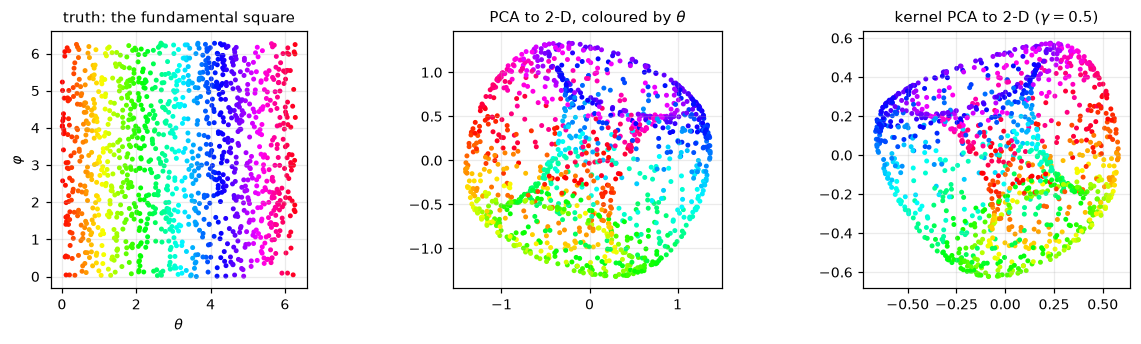

In [5]:
# --- obstruction 3: is any direction distinguished from any other?
lin_t, var_t, _ = pca(T_flat, k=2)
kpc_t = kernel_pca(T_flat, gamma=0.5, k=2)

print("PCA variances:", "  ".join(f"{v:.4f}" for v in var_t),
      f"  (total {var_t.sum():.3f}; var(cos) = 0.5 in every direction)")
C = np.cov(T_flat.T, bias=True)
print(f"covariance is 0.5 * I_4 to within sampling noise: "
      f"max |off-diagonal| = {np.abs(C - np.diag(np.diag(C))).max():.3f}")
print(f"top 2 of 4 keep {var_t[:2].sum() / var_t.sum():.1%} of the sample variance, but the population"
      f"\nvalue is exactly 50% for EVERY 2-plane; the excess is the upward bias of"
      f"\ntaking the larger two of four noisy estimates.")

# eigenvalue = squared column norm, since kernel_pca returns eigenvectors * sqrt(eigenvalue)
kev = (kernel_pca(T_flat, gamma=0.5, k=6)**2).sum(0)
print("\nkernel PCA eigenvalues:", "  ".join(f"{v:.1f}" for v in kev))
print("four nearly equal, then a clear drop: no preferred direction there either.")

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2))
axes[0].scatter(th, ph, c=th, cmap="hsv", s=5)
axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$\varphi$")
axes[0].set_title("truth: the fundamental square")
axes[1].scatter(*lin_t.T, c=th, cmap="hsv", s=5)
axes[1].set_title(r"PCA to 2-D, coloured by $\theta$")
axes[2].scatter(*kpc_t.T, c=th, cmap="hsv", s=5)
axes[2].set_title(r"kernel PCA to 2-D ($\gamma = 0.5$)")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### Obstruction 3 — there is no preferred direction to find

All four variances come out $\approx 0.5$, and that is not an accident of this
sample. The two angles are independent and uniform, so $\mathrm{E}[\cos^2\theta] =
\tfrac12$, $\mathrm{E}[\cos\theta\sin\theta] = 0$, and $\mathrm{E}[\cos\theta\cos\varphi]
= \mathrm{E}[\cos\theta]\,\mathrm{E}[\cos\varphi] = 0$: the population covariance is
exactly $\tfrac12 I_4$. The printed off-diagonals confirm it to within $0.03$.

An isotropic covariance has **no eigenbasis of its own**. Every orthonormal frame
diagonalises it, and every 2-plane captures exactly half the variance. So the plane
PCA hands back is selected purely by sampling noise — redraw the $1200$ points and
you get an unrelated one — and the $53.3\%$ printed above is not a genuine margin
over $50\%$, only the bias you always incur by keeping the largest two of four noisy
estimates. This is a different failure from §1's. There, PCA answered a well-posed
question we had not asked; here the question it asks has no answer at all.

The middle panel shows what an arbitrary 2-plane does: it superposes the two circle
factors into a **filled disc**. The $\theta$ colouring locates the damage precisely.
Around the rim the hues still run in order, so points there keep their neighbours;
towards the centre the colours interleave, because that is where pairs with very
different $(\theta, \varphi)$ cancel in the projection and pile up on each other.
§4 will attach a number to it — PCA retains only $43.5\%$ of each point's true
nearest neighbours.

**And the kernel does not rescue it**, which is why the third panel is here. In §2
the obstruction was one of *expressiveness*: the discriminating coordinate
$\lVert x \rVert$ was a nonlinear function of the input, invisible to any linear
coordinate, and a kernel could build it. Here there is nothing distinguished to
build. The RBF Gram matrix carries the same signature — four nearly equal leading
eigenvalues ($130.4,\, 119.3,\, 112.6,\, 105.2$) before a clear drop to $56.5$ — so
its top two components are again an arbitrary 2-plane inside a degenerate block, and
its picture is another disc. **A kernel changes which functions you can express; it
cannot manufacture a preferred direction in an object that has none.**

That is obstructions 1, 2 and 3 accounted for. The fourth is topological, and it
stays invisible until a method actually tries to preserve neighbourhoods.

---
## 4. t-SNE: excellent at neighbourhoods, unreliable at everything else

t-SNE abandons distances altogether and matches **neighbourhood probabilities**. In
the data it defines $p_{ij}$ from Gaussian affinities with a bandwidth chosen per
point so that the effective number of neighbours equals a set **perplexity**; in the
plane it defines $q_{ij}$ from a heavy-tailed Student-$t$ kernel; and it minimises
$\mathrm{KL}(p\,\|\,q)$ by gradient descent.

The asymmetry of the KL divergence is the whole character of the method. A large
$p_{ij}$ paired with a small $q_{ij}$ is punished heavily — so **near points must
stay near**. A small $p_{ij}$ paired with a large $q_{ij}$ costs almost nothing — so
**far points may go anywhere**. t-SNE is therefore a statement about local
neighbourhoods and, deliberately, not about global geometry.

In [6]:
def tsne(D, perplexity=30, dim=2, iters=500, lr=200.0, rng=None):
    """A compact t-SNE. D is the matrix of input distances."""
    n = len(D)
    # per-point bandwidths chosen by bisection to hit the target perplexity
    P = np.zeros((n, n))
    logU = np.log(perplexity)
    for i in range(n):
        lo, hi, beta = -np.inf, np.inf, 1.0
        Di = np.delete(D[i]**2, i)
        for _ in range(50):
            Pi = np.exp(-Di * beta)
            s = Pi.sum() + 1e-12
            H = np.log(s) + beta * (Di * Pi).sum() / s
            if abs(H - logU) < 1e-5:
                break
            if H > logU:
                lo = beta; beta = beta * 2 if hi == np.inf else (beta + hi) / 2
            else:
                hi = beta; beta = beta / 2 if lo == -np.inf else (beta + lo) / 2
        P[i, np.arange(n) != i] = Pi / s
    P = (P + P.T) / (2 * n)
    P = np.maximum(P, 1e-12)

    Y = 1e-4 * rng.normal(size=(n, dim))
    gains, dY = np.ones_like(Y), np.zeros_like(Y)
    for it in range(iters):
        num = 1.0 / (1.0 + ((Y[:, None] - Y[None])**2).sum(-1))
        np.fill_diagonal(num, 0.0)
        Q = np.maximum(num / num.sum(), 1e-12)
        PQ = (P * 4 if it < 100 else P) - Q          # early exaggeration
        grad = 4 * (((PQ * num)[:, :, None] * (Y[:, None] - Y[None])).sum(1))
        mom = 0.5 if it < 250 else 0.8
        gains = np.where(np.sign(grad) != np.sign(dY), gains + 0.2, gains * 0.8)
        gains = np.maximum(gains, 0.01)
        dY = mom * dY - lr * gains * grad
        Y = Y + dY
        Y -= Y.mean(0)
    return Y


sub = rng.choice(N_T, 600, replace=False)
Y_ts = tsne(D_ambient[np.ix_(sub, sub)], perplexity=30,
            rng=np.random.default_rng(0))
print("t-SNE done:", Y_ts.shape)

t-SNE done: (600, 2)


method       kNN preserved    corr with geodesic
PCA                  43.5%                 0.637
t-SNE                81.5%                 0.560


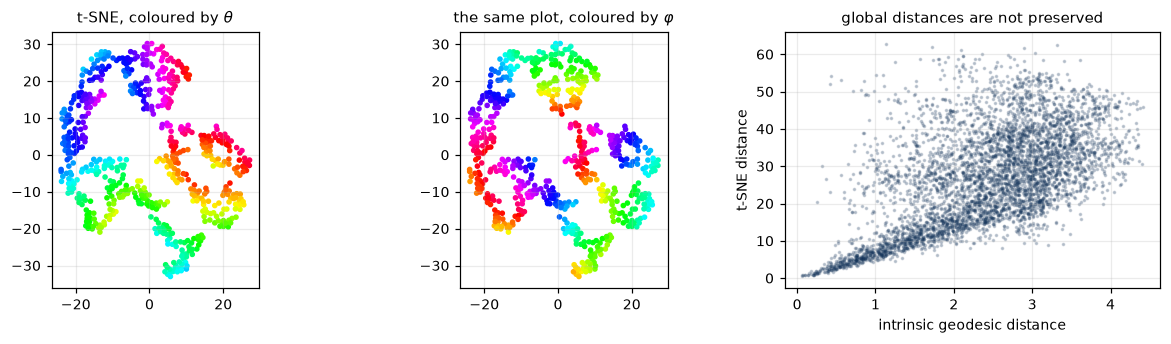

In [7]:
def trustworthiness_knn(D_hi, D_lo, k=12):
    """Fraction of each point's k nearest neighbours that survive the embedding."""
    n = len(D_hi)
    nn_hi = np.argsort(D_hi, axis=1)[:, 1:k + 1]
    nn_lo = np.argsort(D_lo, axis=1)[:, 1:k + 1]
    return np.mean([len(set(a) & set(b)) / k for a, b in zip(nn_hi, nn_lo)])


D_sub_amb = D_ambient[np.ix_(sub, sub)]
D_sub_int = D_intrinsic[np.ix_(sub, sub)]
D_ts = np.sqrt(((Y_ts[:, None] - Y_ts[None])**2).sum(-1))
D_pca = np.sqrt(((lin_t[sub][:, None] - lin_t[sub][None])**2).sum(-1))

print(f"{'method':10s} {'kNN preserved':>15s} {'corr with geodesic':>21s}")
iu2 = np.triu_indices(len(sub), 1)
for name, Dl in [("PCA", D_pca), ("t-SNE", D_ts)]:
    print(f"{name:10s} {trustworthiness_knn(D_sub_amb, Dl):15.1%} "
          f"{np.corrcoef(Dl[iu2], D_sub_int[iu2])[0,1]:21.3f}")

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2))
axes[0].scatter(*Y_ts.T, c=th[sub], cmap="hsv", s=7)
axes[0].set_title(r"t-SNE, coloured by $\theta$"); axes[0].set_aspect("equal")
axes[1].scatter(*Y_ts.T, c=ph[sub], cmap="hsv", s=7)
axes[1].set_title(r"the same plot, coloured by $\varphi$"); axes[1].set_aspect("equal")
axes[2].scatter(D_sub_int[iu2][::37], D_ts[iu2][::37], s=2, alpha=0.2, color=GEO_DARK)
axes[2].set_xlabel("intrinsic geodesic distance"); axes[2].set_ylabel("t-SNE distance")
axes[2].set_title("global distances are not preserved")
plt.tight_layout(); plt.show()

Read the table first. t-SNE preserves a far larger fraction of each point's nearest
neighbours than PCA does — that is what it optimises, and it delivers. Its
correlation with *global* geodesic distance is poor, and PCA's is better. Neither
number is a defect; they are the specification.

The two colourings make the point visually. Both circle factors vary smoothly across
the picture, so the local structure is right, but the torus has been **torn**: it is
a closed surface with no boundary, and any injective continuous map to the plane must
cut it open. The tear you see is not an artefact to be tuned away; it is forced by
topology, and it will appear in every planar embedding of every closed surface you
ever produce.

That is the cost side, and §3 predicted most of it. But a specification is a promise
as well as a limit, so it is worth one experiment on the other half: on data built to
suit it, how much does the method actually deliver, and how reliably?

12 clusters in R^50; their centres span an affine subspace of dimension 11.
centre covariance eigenvalues: 3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  0.0
11 equal, then 0 — isotropic in that subspace, so PCA has no preferred plane (cf. §3).

                      method   groups resolved   neighbour purity
                  PCA to 2-D            4 / 12             66.3%
t-SNE  perplexity 30, seed 0           12 / 12            100.0%
t-SNE  perplexity 30, seed 1           12 / 12            100.0%
t-SNE  perplexity 50, seed 0           12 / 12            100.0%
t-SNE  perplexity 50, seed 1           12 / 12            100.0%

purity expected by chance: 8.3%


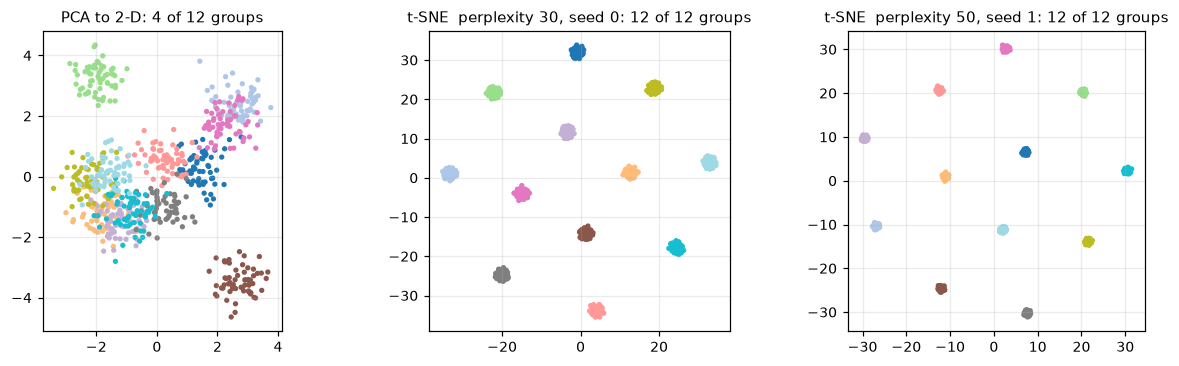

In [8]:
# 12 clusters in R^50 whose centres are a regular simplex: all pairwise distances
# equal, spanning an 11-dimensional affine subspace. A private generator, so the seeded `rng` above is untouched.
K_C, D_C, N_C = 12, 50, 60
rc = np.random.default_rng(3)
Q_C, _ = np.linalg.qr(rc.normal(size=(D_C, K_C)))
centres = 6.0 * Q_C.T
X_cl = np.repeat(centres, N_C, axis=0) + 0.45 * rc.normal(size=(K_C * N_C, D_C))
y_cl = np.repeat(np.arange(K_C), N_C)

Cc = centres - centres.mean(0)
print(f"{K_C} clusters in R^{D_C}; their centres span an affine subspace of dimension "
      f"{np.linalg.matrix_rank(Cc)}.")
print("centre covariance eigenvalues:",
      "  ".join(f"{v:.1f}" for v in np.linalg.eigvalsh(Cc.T @ Cc / K_C)[::-1][:K_C]))
print("11 equal, then 0 — isotropic in that subspace, so PCA has no preferred plane (cf. §3).\n")


def label_purity(Z, y, k=12):
    """Of each point's k nearest neighbours IN THE PLOT, the fraction carrying the same
    label; averaged over points. Chance is 1/K for K equal classes."""
    Dz = np.sqrt(((Z[:, None] - Z[None])**2).sum(-1))
    nn = np.argsort(Dz, axis=1)[:, 1:k + 1]
    return (y[nn] == y[:, None]).mean()


def clusters_resolved(Z, y, K):
    """How many groups a reader could actually pick out: those whose centroid is further
    from the nearest other centroid than twice their own mean radius."""
    cs = np.array([Z[y == j].mean(0) for j in range(K)])
    rad = np.array([np.linalg.norm(Z[y == j] - cs[j], axis=1).mean() for j in range(K)])
    d = np.sqrt(((cs[:, None] - cs[None])**2).sum(-1))
    np.fill_diagonal(d, np.inf)
    return int(sum(d[j].min() > 2 * rad[j] for j in range(K)))


D_cl = np.sqrt(((X_cl[:, None] - X_cl[None])**2).sum(-1))
shown = [("PCA to 2-D", pca(X_cl, k=2)[0])]
for perp in (30, 50):
    for seed in (0, 1):
        shown.append((f"t-SNE  perplexity {perp}, seed {seed}",
                      tsne(D_cl, perplexity=perp, rng=np.random.default_rng(seed))))

print(f"{'method':>28s}{'groups resolved':>18s}{'neighbour purity':>19s}")
for name, Z in shown:
    print(f"{name:>28s}{f'{clusters_resolved(Z, y_cl, K_C)} / {K_C}':>18s}"
          f"{label_purity(Z, y_cl):18.1%}")
print(f"\npurity expected by chance: {1 / K_C:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.4))
for ax, (name, Z) in zip(axes, [shown[0], shown[1], shown[4]]):
    ax.scatter(*Z.T, c=y_cl, cmap="tab20", s=6)
    ax.set_title(f"{name}: {clusters_resolved(Z, y_cl, K_C)} of {K_C} groups")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### What the method is for

**PCA cannot win here, and the reason is a dimension count.** Twelve cluster centres
placed as a regular simplex span an $11$-dimensional affine subspace, and the printed
eigenvalues show the covariance is isotropic inside it — the same degeneracy that
defeated PCA on the flat torus in §3, so again no plane is preferred. But whichever plane it takes, it is
asking twelve mutually equidistant points to stay apart in two dimensions, and they
cannot. Four groups survive; the other eight land on top of one another, and purity
falls to two thirds.

**t-SNE resolves all twelve, at every perplexity and seed tried.** It never projects.
It places points in the plane to match neighbourhood probabilities, and the
$11$-dimensional arrangement of the centres is simply not an obstacle to that: the
only thing it has to get right is who is close to whom. Purity is $100\%$ against a
chance level of $8.3\%$.

This is the case the method exists for, and it is worth being precise about what
makes it easy. Well-separated compact groups are exactly what the asymmetric KL
objective protects: large $p_{ij}$ within a cluster must stay large, and the cost of
misplacing whole clusters relative to each other is nearly nil — which does not
matter, because here there is nothing to learn from where the clusters sit. The
torus was the hard case for the same reason, read backwards: everything worth knowing
about it was in the global arrangement, and that is what the objective declines to
protect. One specification, two verdicts.

**One warning against over-reading this.** The group count is trustworthy *here*
because the groups are genuine metric clusters — the gaps between them are large
compared with their radii, which is precisely what `clusters_resolved` checks. It
does not follow that you may count blobs in general. On a connected manifold like the
torus the pieces you see are tear lines, and their number is a property of the run;
§2's shells are the intermediate case, two labels that are not two clusters, since a
point on the outer shell lies $4.68$ from its own antipode but only $1.2$ from the
inner shell. Before trusting a blob count, ask whether your groups are separated in
the metric or merely different in kind.

Hence the discipline for reading such plots, which is the practical content of this
tutorial:

- **Believe**: which points are near which. That is what the objective controls.
- **Do not believe**: distances between clusters, the sizes of clusters, empty space,
  or the number of components. These are all essentially free under the loss.
- **Always vary the perplexity and the seed** before drawing a conclusion. If a
  feature is not stable across both, it is not a feature of your data.

> **Exercise 2 — stress-test the picture.**
> (a) The clusters above were the easy case, and every run agreed. Do the same on the
> torus, where they will not: re-run at perplexities $5, 30, 100$ with three seeds
> each, and say which features survive all nine runs. With no labels to compute purity
> from, what do you use in its place?
>
> (b) Feed t-SNE the **intrinsic** distance matrix `D_sub_int` instead of the
> ambient one. The tear should remain (topology), but the local geometry should
> improve — measure both claims.
>
> (c) Compute the two diagnostics above for a range of perplexities and plot the
> trade-off between neighbourhood preservation and global-distance correlation.
> There is no setting that maximises both; explain why in terms of the KL objective.

> **Exercise 3 — UMAP, and a fair comparison.**
> Install `umap-learn` (`pip install umap-learn`) and embed the same torus. UMAP
> optimises a different objective built from a fuzzy simplicial complex, and it is
> usually claimed to preserve global structure better. Test that claim with the same
> two numbers rather than by eye. Then try both methods on the sphere of §1, where
> you know the answer, before trusting either on data where you do not.

---
## 5. What to take away

- **PCA is an eigenproblem and finds the smallest affine subspace containing your
  data.** On the sphere in $\mathbb{R}^{60}$ it correctly reports $3$ — the
  dimension of the span, not the $2$ of the manifold. Know which question you asked.
- **Kernel PCA moves the eigenproblem into a feature space** and needs only inner
  products. It separates what no linear coordinate can — at the price of components
  with no interpretation back in the original space, and a kernel width that is
  really a choice of geometry.
- **Some distortion is forced.** The flat torus admits no *smooth* isometric
  copy in $\mathbb{R}^3$ and no injective planar image at all, so every picture of it lies;
  the honest question is only *how*.
- **t-SNE optimises neighbourhoods and nothing else.** It preserves $k$-NN structure
  far better than PCA and global distances far worse, exactly as its asymmetric KL
  objective specifies.
- **And on the data it is built for, it simply works.** Twelve clusters in
  $\mathbb{R}^{50}$ whose centres span an $11$-dimensional affine subspace: PCA can
  resolve four of them, by a dimension count it cannot argue with, while t-SNE
  resolves all twelve at every perplexity and seed. Turn the knobs; what does not
  move is what you may act on.
- **Measure the distortion rather than eyeballing it.** Neighbourhood preservation
  and correlation with true geodesic distance are two numbers, cheap to compute, and
  they turn "this looks like clusters" into a claim you can defend.

### Next

**Lecture 9** changes the setting entirely: no fixed dataset at all, but an agent
generating its own data by acting. **Tutorial 9** puts a Markov decision process on a
triangulation.

### Further reading

- Schölkopf, Smola & Müller, "Nonlinear component analysis as a kernel eigenvalue problem", *Neural Computation* **10** (1998) — kernel PCA, §2.
- van der Maaten & Hinton, "Visualizing data using t-SNE", *JMLR* **9** (2008).
- Wattenberg, Viégas & Johnson, "How to use t-SNE effectively", *Distill* (2016) — the interactive version of §4's cautions; strongly recommended.
- McInnes, Healy & Melville, "UMAP", arXiv:1802.03426 — Exercise 3.